# Reading and visualising an optimisation

The [Pareto example](pareto) runs a minimal two-objective search. Here we run a
slightly larger **three-objective** optimisation and focus on the tools for making
sense of the result: the several views of the Pareto front, the per-generation
history, a convergence trace, and reading the result tables programmatically.

The three objectives — minimise peak surface **electric** field, minimise peak
surface **magnetic** field, and maximise **R/Q** — genuinely conflict, so there is
a real trade-off surface to explore. See the [optimisation guide](../../optimisation).

In [1]:
import os
import tempfile
import warnings

import matplotlib.pyplot as plt

from cavsim2d import Study, EllipticalCavity
from cavsim2d.utils.style import apply_style

warnings.filterwarnings('ignore')   # quiet matplotlib tight_layout notices
apply_style()

## 1. A three-objective search

`bounds` are the swept design variables; `Req` is tuned separately (via
`tune_config`) to keep every candidate on 1300 MHz, so it is not a bound. Kept
small — a handful of candidates over two generations — so it runs in a few minutes.

  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:54<00:54, 54.54s/it]

100%|██████████| 2/2 [02:32<00:00, 80.22s/it]

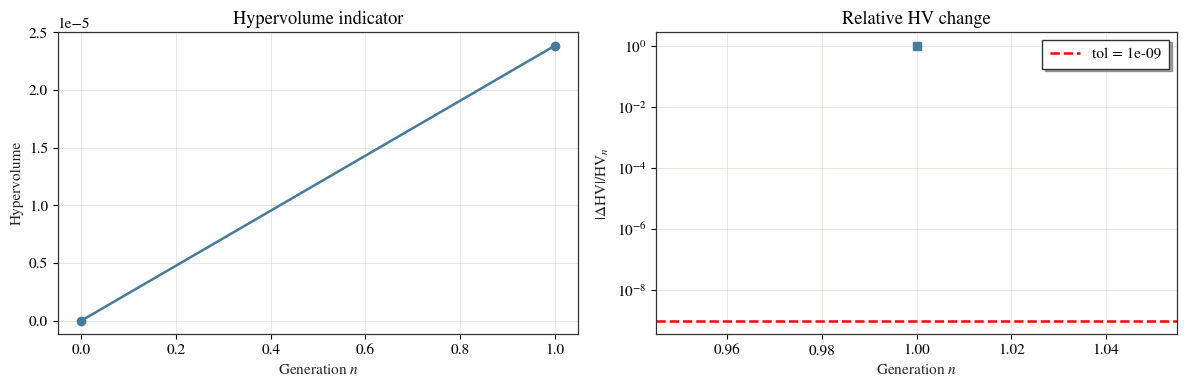

evaluated candidates: 16
Pareto-front size:    4
objectives:           ['monopole:Epk/Eacc []', 'monopole:Bpk/Eacc [mT/MV/m]', 'monopole:R/Q [Ohm]']


In [2]:
cavs = Study(os.path.join(tempfile.mkdtemp(), 'opt3'))
mid = [42, 42, 12, 19, 35, 57.7, 103.353]
cavs.add_cavity([EllipticalCavity(1, mid, mid, mid, beampipe='none')], ['TESLA'])

config = {
    'initial_points': 6, 'no_of_generation': 2, 'method': {'LHS': {'seed': 5}},
    'bounds': {'A': [38, 48], 'B': [38, 48], 'a': [10, 14], 'b': [17, 21]},
    'objectives': [['min', 'monopole:Epk/Eacc []'],
                   ['min', 'monopole:Bpk/Eacc [mT/MV/m]'],
                   ['max', 'monopole:R/Q [Ohm]']],
    'tune_config': {'freqs': 1300.0, 'cell_type': {'mid-cell': 'Req'}, 'processes': 1,
                    'eigenmode_config': {'n_cells': 1, 'processes': 1,
                                         'boundary_conditions': 'mm'}},
    'mutation_factor': 4, 'crossover_factor': 4, 'elites_for_crossover': 2,
    'chaos_factor': 2, 'weights': [1, 1, 1],
}
cavs.run_optimisation(config)
opt = cavs.optimisation
print(f'evaluated candidates: {len(opt.history)}')
print(f'Pareto-front size:    {len(opt.pareto)}')
print(f'objectives:           {opt.objective_vars}')

## 2. The Pareto front, several ways

With three objectives a single scatter plot cannot show every trade-off at once, so
the optimiser offers complementary views (`kind=`). The **scatter matrix** shows
every pair of objectives:

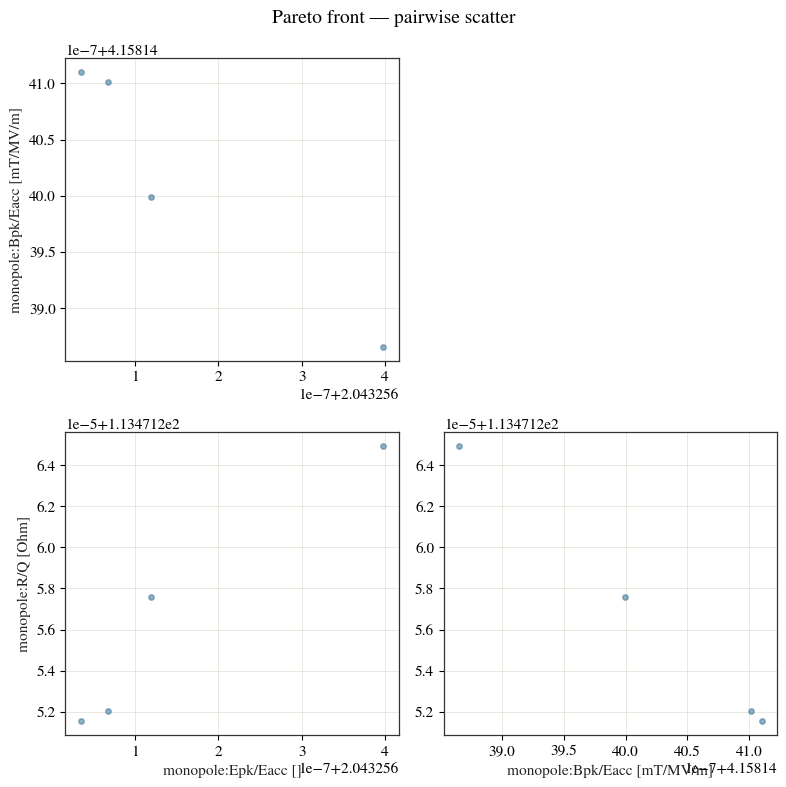

(<Figure size 800x800 with 4 Axes>,
 array([[<Axes: ylabel='monopole:Bpk/Eacc [mT/MV/m]'>, <Axes: >],
        [<Axes: xlabel='monopole:Epk/Eacc []', ylabel='monopole:R/Q [Ohm]'>,
         <Axes: xlabel='monopole:Bpk/Eacc [mT/MV/m]'>]], dtype=object))

In [3]:
opt.plot_pareto(kind='scatter', normalise=False)

**Parallel coordinates** (`pcp`) draws each candidate as a line across all three
objective axes — crossing lines are the sign of a trade-off:

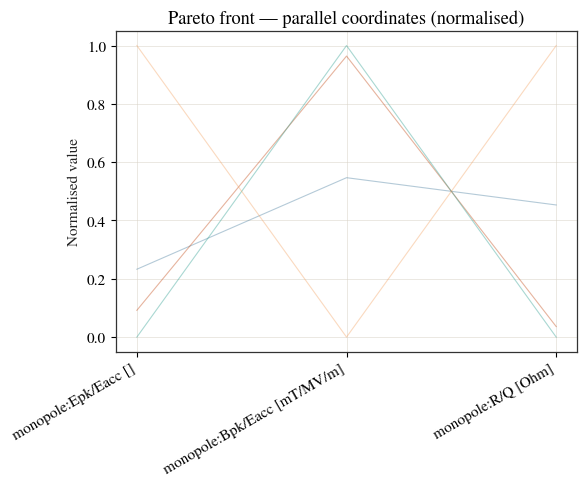

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Pareto front — parallel coordinates (normalised)'}, ylabel='Normalised value'>)

In [4]:
opt.plot_pareto(kind='pcp')

A **radar** plot gives each Pareto candidate its own polygon over the (normalised)
objectives — a compact fingerprint of where each design is strong:

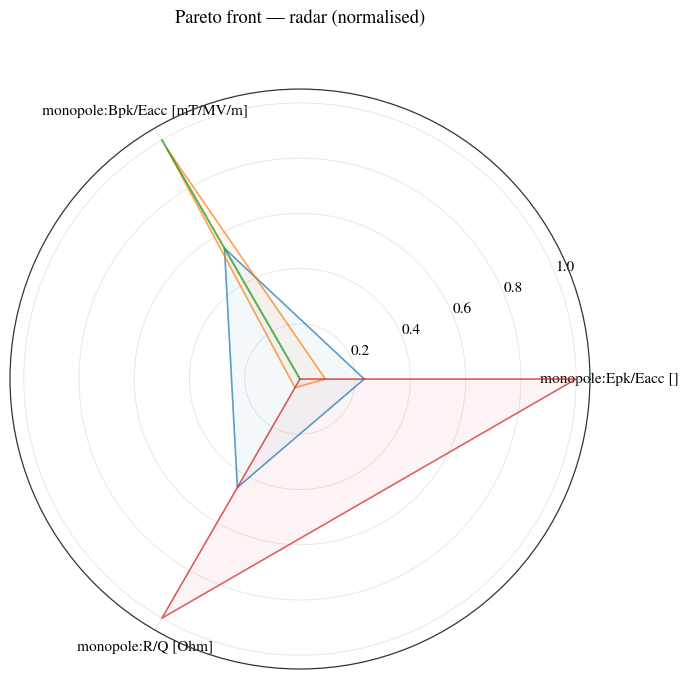

(<Figure size 700x700 with 1 Axes>,
 <PolarAxes: title={'center': 'Pareto front — radar (normalised)'}>)

In [5]:
opt.plot_pareto(kind='radar')

## 3. How the search progressed

`plot_history` colours every evaluated candidate by the generation it was born in,
so you can watch the population march toward the front:

100%|██████████| 2/2 [02:33<00:00, 76.80s/it]

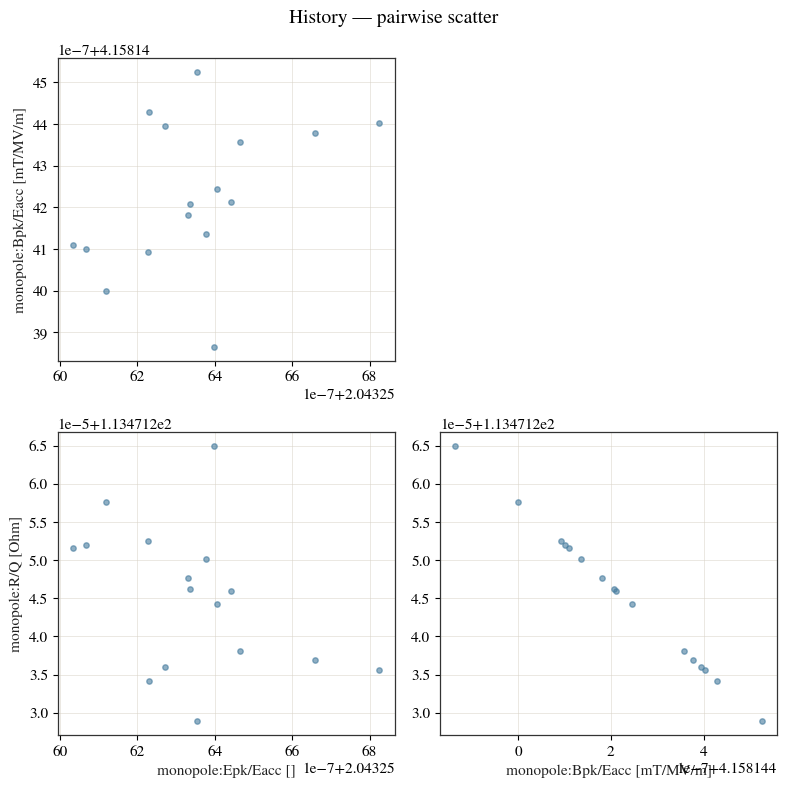

(<Figure size 800x800 with 4 Axes>,
 array([[<Axes: ylabel='monopole:Bpk/Eacc [mT/MV/m]'>, <Axes: >],
        [<Axes: xlabel='monopole:Epk/Eacc []', ylabel='monopole:R/Q [Ohm]'>,
         <Axes: xlabel='monopole:Bpk/Eacc [mT/MV/m]'>]], dtype=object))

In [6]:
opt.plot_history(kind='scatter', color_by_gen=True, normalise=False)

`plot_pareto_history` overlays the non-dominated front from each generation:

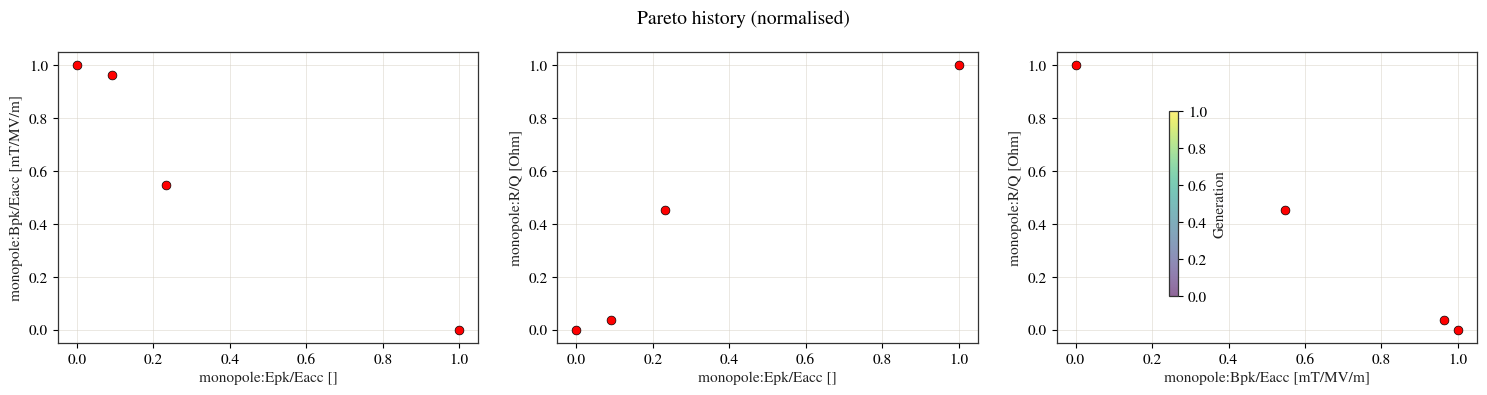

(<Figure size 1500x400 with 4 Axes>,
 {'monopole:Epk/Eacc [] vs monopole:Bpk/Eacc [mT/MV/m]': <Axes: label='monopole:Epk/Eacc [] vs monopole:Bpk/Eacc [mT/MV/m]', xlabel='monopole:Epk/Eacc []', ylabel='monopole:Bpk/Eacc [mT/MV/m]'>,
  'monopole:Epk/Eacc [] vs monopole:R/Q [Ohm]': <Axes: label='monopole:Epk/Eacc [] vs monopole:R/Q [Ohm]', xlabel='monopole:Epk/Eacc []', ylabel='monopole:R/Q [Ohm]'>,
  'monopole:Bpk/Eacc [mT/MV/m] vs monopole:R/Q [Ohm]': <Axes: label='monopole:Bpk/Eacc [mT/MV/m] vs monopole:R/Q [Ohm]', xlabel='monopole:Bpk/Eacc [mT/MV/m]', ylabel='monopole:R/Q [Ohm]'>})

In [7]:
opt.plot_pareto_history()

and `plot_convergence` tracks a scalar fitness against generation:

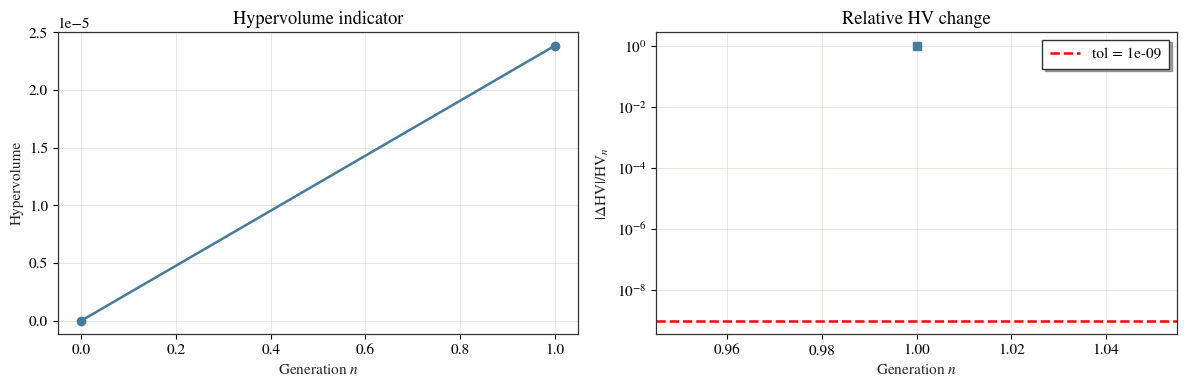

(<Figure size 1200x400 with 2 Axes>,
 (<Axes: title={'center': 'Hypervolume indicator'}, xlabel='Generation $n$', ylabel='Hypervolume'>,
  <Axes: title={'center': 'Relative HV change'}, xlabel='Generation $n$', ylabel='$|\\Delta \\mathrm{HV}| / \\mathrm{HV}_n$'>))

In [8]:
opt.plot_convergence()

## 4. Reading the results

Everything is a DataFrame. `opt.pareto` holds the non-dominated designs — their
geometry variables and objective values — ready to sort and pick from.

In [9]:
obj = opt.objective_vars
cols = ['A', 'B', 'a', 'b'] + obj
opt.pareto[cols].round(3)

,A,B,a,b,monopole:Epk/Eacc [],monopole:Bpk/Eacc [mT/MV/m],monopole:R/Q [Ohm]
0,45.500,38.833,12.333,18.000,2.043,4.158,113.471
1,40.500,40.500,13.000,20.000,2.043,4.158,113.471
2,43.833,43.833,11.000,19.333,2.043,4.158,113.471
3,46.488,41.935,13.165,17.098,2.043,4.158,113.471


For example, the lowest-peak-field design on the front:

In [10]:
best = opt.pareto.sort_values('monopole:Epk/Eacc []').iloc[0]
print(best[cols].round(3).to_string())

A                               43.833
B                               43.833
a                               11.000
b                               19.333
monopole:Epk/Eacc []             2.043
monopole:Bpk/Eacc [mT/MV/m]      4.158
monopole:R/Q [Ohm]             113.471
